# Chromosome, Replicate 1 Scripting

Create a script to run the deconvolution on each replicate. This notebook will test the script.


In [119]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [120]:
from pipeline.fit_replication_profiles import main
from src.utils import mkdir_safe

output_directory = "output/prototype_pipeline_subset_stage2/"


In [354]:
from pipeline.fit_replication_profiles import main as fit_replication_profile
from src.utils import print_fl
from src.config import load_default_chrom_configs, load_cloccs_configs
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.optimize_H import create_bounds_params_from_config

cold_start = False
chrom = 4
replicate = 1
num_epochs = 10
config = None
config, _ = load_cloccs_configs()

np.random.seed(123)

update_params_df, replication_deconvolver, optimizer = fit_replication_profile(chrom=chrom, 
    replicate=replicate, num_epochs=num_epochs, output_directory=output_directory, 
    save=False, config=config,
    learn_subset_parameters=['mu0', 'sigma0', 'gamma2'])

Loading MNase data
Omit windows with less than 75% read coverage.
Running initial iterations...
Deconvolving 702 regions
Initializing B using timepoint 0
Subsetting the cell cycle parameters to learn:  ['mu0', 'sigma0', 'gamma2']
[0] 00:00:00.316, rn=0.0325080964493636
[1] 00:00:00.605, rn=0.005336986859565165
[2] 00:00:00.922, rn=0.004873615021913086
[3] 00:00:01.332, rn=0.004540598217735929
[4] 00:00:01.637, rn=0.004330805574857863
[5] 00:00:01.887, rn=0.0042284662995368165
[6] 00:00:02.131, rn=0.004176609139330678
[7] 00:00:02.382, rn=0.004142511300327905
[8] 00:00:02.631, rn=0.0041229622059889715
[9] 00:00:02.877, rn=0.0041142415857645855
[10] 00:00:03.151, rn=0.004110290274690468
[11] 00:00:03.402, rn=0.004108542848186084
[12] 00:00:03.644, rn=0.004107602850057142
[13] 00:00:03.889, rn=0.004106924785684618
[14] 00:00:04.135, rn=0.0041065117489747435
[15] 00:00:04.390, rn=0.004106258914930721
[16] 00:00:04.635, rn=0.004106006010701572
[17] 00:00:04.880, rn=0.0041058369725573305
[18

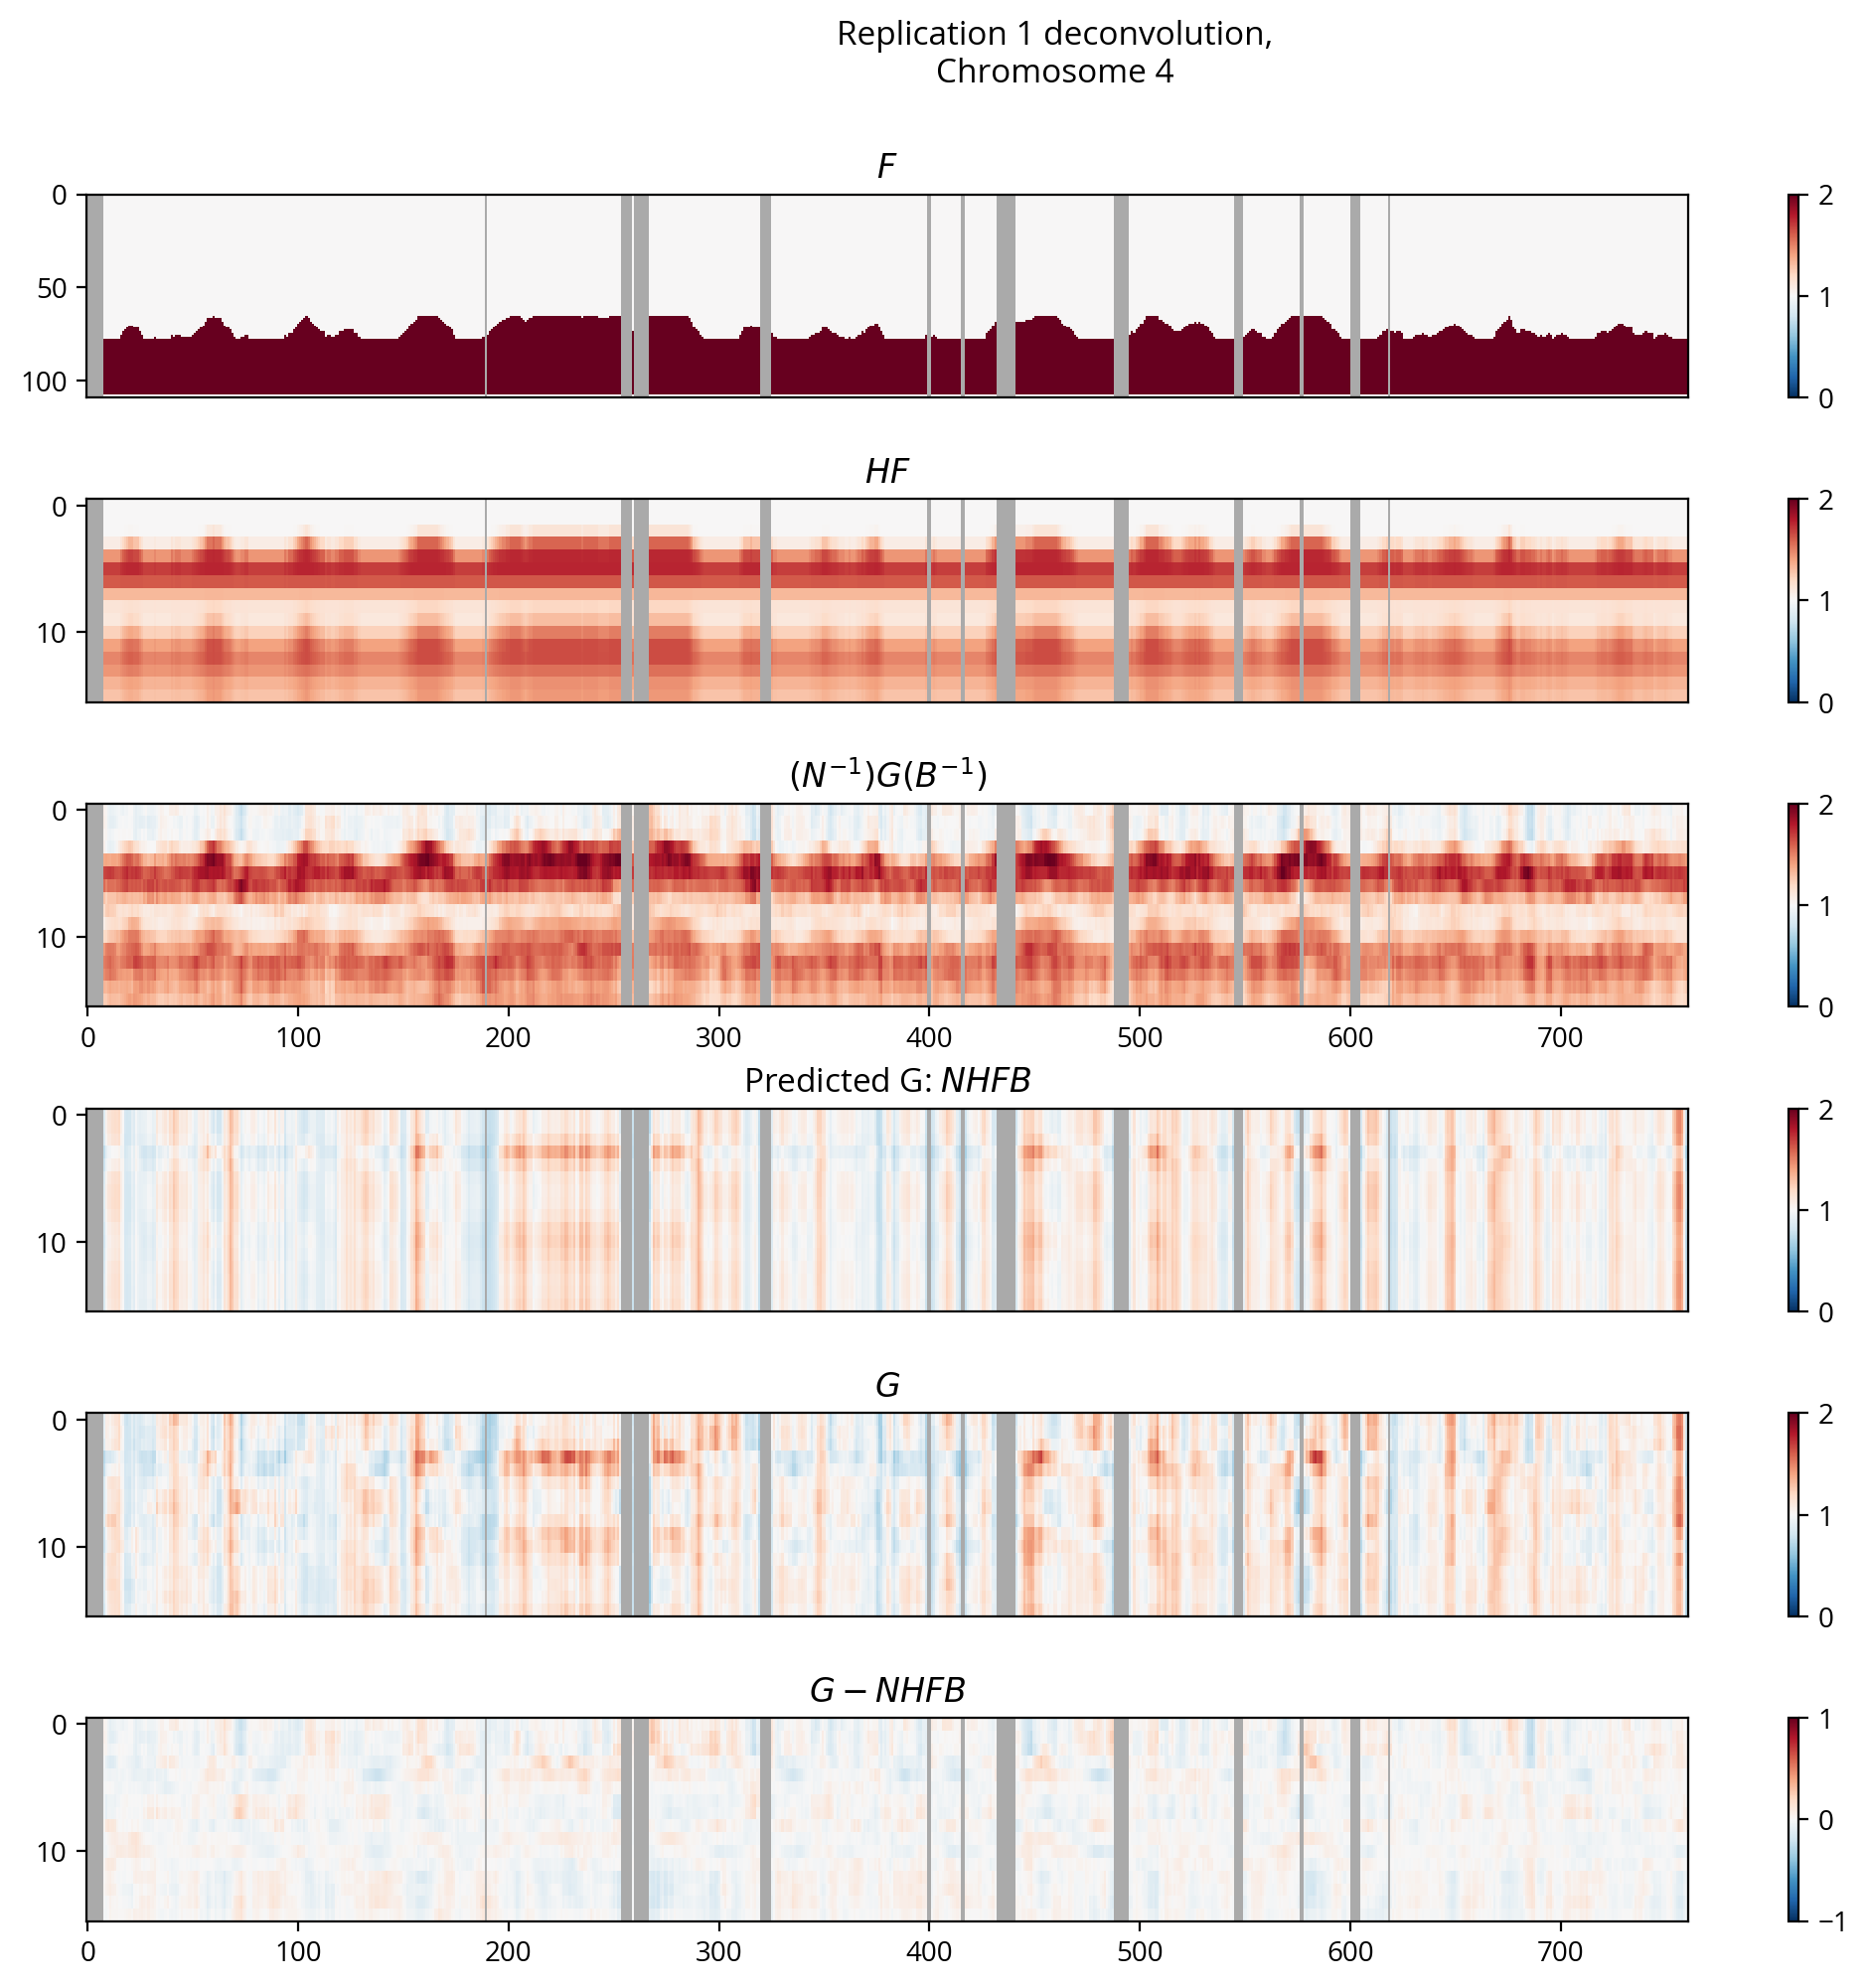

In [355]:
fig = replication_deconvolver.plot_heatmaps()